In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [ ]:
# ==========================================
# 1. KONFIGURASI PARAMETER (TERKALIBRASI REALISTIS)
# ==========================================
start_date = date(2023, 1, 1)
end_date = date(2045, 12, 31)
days = (end_date - start_date).days + 1

# --- A. Historis Wisatawan ---
dom_2023, man_2023 = 355297, 13210
dom_2024, man_2024 = 465751, 19926
dom_2025_est = 390487 * (12 / 9)
man_2025_est = 13300 * (12 / 9)

r_dom_23_24 = (dom_2024 / dom_2023) ** (1 / 365) - 1
r_man_23_24 = (man_2024 / man_2023) ** (1 / 365) - 1
r_dom_24_25 = (dom_2025_est / dom_2024) ** (1 / 365) - 1
r_man_24_25 = (man_2025_est / man_2024) ** (1 / 365) - 1
daily_growth_bau = (1 + 0.0468) ** (1 / 365) - 1

# --- B. Parameter Finansial & Infrastruktur ---
avg_tiket_dom = ((5 * 54000) + (2 * 79000)) / 7
avg_tiket_man = 255000
persentase_retribusi = 0.85
initial_stock_anggaran = 3_976_500_000

initial_kapasitas = 2752

# KALIBRASI: Alokasi belanja fisik diturunkan agar realistis (biaya operasional taman nasional sangat tinggi)
alokasi_belanja_modal = 0.18
biaya_per_unit_kapasitas = 20_000_000

depresiasi_tahunan = 0.143
depresiasi_harian = 1 - (1 - depresiasi_tahunan)**(1/365)
faktor_kerusakan_overuse = 0.0008

In [ ]:
# ==========================================
# 2. MESIN SIMULASI (CAUSAL LOOP)
# ==========================================
dates = []
data_visitors = []
data_kapasitas = []

curr_dom_bau, curr_man_bau = dom_2023 / 365, man_2023 / 365
stock_kapasitas = initial_kapasitas
stock_anggaran = initial_stock_anggaran
reputasi_bau = 1.0
lama_tinggal = 3

curr_date = start_date

for _ in range(days):
    dates.append(curr_date)
    year = curr_date.year

    if year == 2023:
        g_dom, g_man = r_dom_23_24, r_man_23_24
    elif year == 2024:
        g_dom, g_man = r_dom_24_25, r_man_24_25
    else:
        g_dom, g_man = daily_growth_bau, daily_growth_bau

    pop_today = curr_dom_bau + curr_man_bau
    if pop_today > 2752:
        reputasi_bau -= (pop_today / 2752 - 1.0) * 0.0004
    reputasi_bau = max(0.80, reputasi_bau)

    outflow_dom = curr_dom_bau / lama_tinggal
    outflow_man = curr_man_bau / lama_tinggal

    inflow_dom = (outflow_dom + curr_dom_bau * g_dom) * reputasi_bau
    inflow_man = (outflow_man + curr_man_bau * g_man) * reputasi_bau

    curr_dom_bau += (inflow_dom - outflow_dom)
    curr_man_bau += (inflow_man - outflow_man)
    current_visitors = curr_dom_bau + curr_man_bau

    pendapatan_harian = ((curr_dom_bau * avg_tiket_dom) + (curr_man_bau * avg_tiket_man)) * persentase_retribusi
    rasio_penyerapan_tahunan = 0.90
    rasio_penyerapan_harian = 1 - (1 - rasio_penyerapan_tahunan)**(1/365)
    total_belanja = stock_anggaran * rasio_penyerapan_harian
    stock_anggaran = max(0, stock_anggaran + pendapatan_harian - total_belanja)

    belanja_modal_harian = total_belanja * alokasi_belanja_modal
    laju_pengadaan = belanja_modal_harian / biaya_per_unit_kapasitas

    kerusakan_alami = stock_kapasitas * depresiasi_harian
    kerusakan_tambahan = max(0, current_visitors - stock_kapasitas) * faktor_kerusakan_overuse
    laju_kerusakan = kerusakan_alami + kerusakan_tambahan

    stock_kapasitas = max(0, stock_kapasitas + laju_pengadaan - laju_kerusakan)

    data_visitors.append(current_visitors)
    data_kapasitas.append(stock_kapasitas)

    curr_date += timedelta(days=1)

In [ ]:
# ==========================================
# 3. DATAFRAME & VISUAL SMOOTHING
# ==========================================
df = pd.DataFrame({"Date": pd.to_datetime(dates), "Kunjungan": data_visitors, "Kapasitas": data_kapasitas})

df["Kunjungan_Smooth"] = df["Kunjungan"].rolling(window=180, min_periods=1, center=True).mean()
df["Kapasitas_Smooth"] = df["Kapasitas"].rolling(window=180, min_periods=1, center=True).mean()

cross = df[df["Kunjungan_Smooth"] > df["Kapasitas_Smooth"]].head(1)

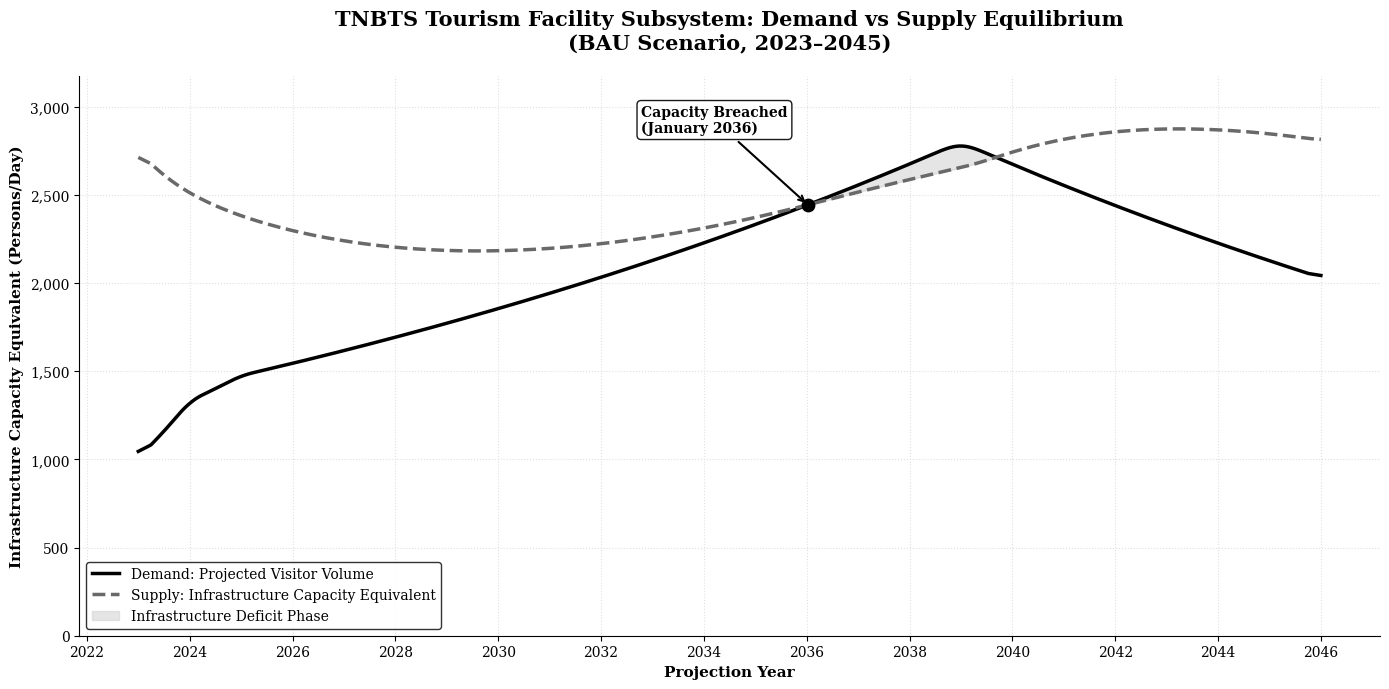

In [ ]:
# ==========================================
# 4. VISUALISASI MONOKROM AKADEMIS (ENGLISH)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif', 'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black',
    'ytick.color': 'black', 'axes.grid': True, 'grid.color': '#e0e0e0',
    'grid.linestyle': ':', 'legend.frameon': True, 'legend.edgecolor': 'black'
})

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df["Date"], df["Kunjungan_Smooth"], color="black", linestyle="-", linewidth=2.5, label="Demand: Projected Visitor Volume")
ax.plot(df["Date"], df["Kapasitas_Smooth"], color="dimgray", linestyle="--", linewidth=2.5, label="Supply: Infrastructure Capacity Equivalent")

ax.fill_between(df["Date"], df["Kapasitas_Smooth"], df["Kunjungan_Smooth"],
                where=(df["Kunjungan_Smooth"] > df["Kapasitas_Smooth"]),
                color="#C0C0C0", alpha=0.4, label="Infrastructure Deficit Phase")

if not cross.empty:
    fail_date = cross["Date"].iloc[0]
    fail_val = cross["Kunjungan_Smooth"].iloc[0]
    ax.scatter(fail_date, fail_val, color="black", s=80, zorder=5)
    ax.annotate(
        f"Capacity Breached\n({pd.to_datetime(fail_date).strftime('%B %Y')})",
        xy=(fail_date, fail_val), xytext=(-120, 50), textcoords="offset points",
        fontsize=10, weight='bold', ha="left", va="bottom",
        arrowprops=dict(arrowstyle="->", color="black", lw=1.5),
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.9)
    )

ax.set_title("TNBTS Tourism Facility Subsystem: Demand vs Supply Equilibrium\n(BAU Scenario, 2023–2045)", fontsize=15, fontweight="bold", pad=20)
ax.set_xlabel("Projection Year", fontsize=11, fontweight="bold")
ax.set_ylabel("Infrastructure Capacity Equivalent (Persons/Day)", fontsize=11, fontweight="bold")

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: format(int(x), ",")))

# PERBAIKAN VISUAL: Limit atas otomatis mendeteksi garis mana pun yang tertinggi
max_y_value = max(df["Kunjungan_Smooth"].max(), df["Kapasitas_Smooth"].max())
ax.set_ylim(bottom=0, top=max_y_value + 300)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="lower left", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 5. EKSPOR DATA TAHUNAN
# ==========================================
df["Year"] = df["Date"].dt.year
df_annual = df.groupby("Year").agg(Kunjungan=("Kunjungan_Smooth", "mean"), Kapasitas=("Kapasitas_Smooth", "mean")).reset_index()

print("\n" + "=" * 80)
print("   TABEL PROYEKSI KESENJANGAN FASILITAS WISATA TNBTS (SKENARIO BAU)")
print("=" * 80)
print(f"{'Tahun':<6} | {'Permintaan (Jiwa/Hari)':<25} | {'Kapasitas (Jiwa/Hari)':<25} | {'Status'}")
print("-" * 80)

for _, row in df_annual[df_annual["Year"] >= 2024].iterrows():
    year = int(row["Year"])
    vis = row["Kunjungan"]
    cap = row["Kapasitas"]
    status = "DEFICIT" if vis > cap else "SUFFICIENT"
    print(f"{year:<6} | {vis:>23,.0f} | {cap:>23,.0f} | {status}")
print("=" * 80)


   TABEL PROYEKSI KESENJANGAN FASILITAS WISATA TNBTS (SKENARIO BAU)
Tahun  | Permintaan (Jiwa/Hari)    | Kapasitas (Jiwa/Hari)     | Status
--------------------------------------------------------------------------------
2024   |                   1,400 |                   2,441 | SUFFICIENT
2025   |                   1,509 |                   2,337 | SUFFICIENT
2026   |                   1,580 |                   2,266 | SUFFICIENT
2027   |                   1,654 |                   2,220 | SUFFICIENT
2028   |                   1,732 |                   2,192 | SUFFICIENT
2029   |                   1,813 |                   2,183 | SUFFICIENT
2030   |                   1,898 |                   2,189 | SUFFICIENT
2031   |                   1,987 |                   2,209 | SUFFICIENT
2032   |                   2,080 |                   2,241 | SUFFICIENT
2033   |                   2,177 |                   2,286 | SUFFICIENT
2034   |                   2,279 |                   2,341

In [ ]:
# ==========================================
# 6. EVALUASI MAPE: SUBSISTEM FASILITAS & INFRASTRUKTUR
# ==========================================

# 1. Masukkan Data Aktual (Riil) Kapasitas Infrastruktur TNBTS
# CATATAN PENTING: Ganti angka di bawah ini dengan data riil estimasi
# daya dukung/kapasitas fasilitas TNBTS (dalam satuan jiwa/hari) untuk tahun 2023 & 2024.
# Jika tidak ada pembangunan baru di 2023-2024, angkanya mungkin tetap di sekitar 2752.
data_aktual_kapasitas = {
    2023: 2752.0,  # Contoh: Kapasitas riil tahun 2023
    2024: 2758.0   # Contoh: Kapasitas riil tahun 2024 (asumsi ada sedikit perbaikan)
}

# Buat DataFrame dari data aktual
df_aktual_infra = pd.DataFrame(list(data_aktual_kapasitas.items()), columns=['Year', 'Aktual_Kapasitas'])

# 2. Gabungkan Data Aktual dengan Data Simulasi (df_annual)
# Kita menggunakan 'Kapasitas' yang sudah diagregasi menjadi rata-rata tahunan di FASE 5
df_eval_infra = pd.merge(df_aktual_infra, df_annual, on='Year', how='inner')

# 3. Hitung Absolute Percentage Error (APE) dan MAPE
df_eval_infra['APE'] = np.abs((df_eval_infra['Aktual_Kapasitas'] - df_eval_infra['Kapasitas']) / df_eval_infra['Aktual_Kapasitas']) * 100
mape_infra = df_eval_infra['APE'].mean()

# 4. Tampilkan Hasil Evaluasi Infrastruktur
print("\n" + "="*75)
print("     EVALUASI MAPE: SUBSISTEM INFRASTRUKTUR & FASILITAS (KAPASITAS)")
print("="*75)
print(df_eval_infra[['Year', 'Aktual_Kapasitas', 'Kapasitas', 'APE']].rename(
    columns={'Aktual_Kapasitas': 'Aktual (Jiwa/Hari)', 'Kapasitas': 'Simulasi (Jiwa/Hari)', 'APE': 'Error (%)'}
).round(2).to_string(index=False))
print("-" * 75)
print(f"NILAI MAPE SUBSISTEM INFRASTRUKTUR : {mape_infra:.2f}%")

# Kategorisasi standar akurasi
if mape_infra < 10:
    kategori_infra = "Sangat Akurat (Highly Accurate)"
elif mape_infra < 20:
    kategori_infra = "Baik (Good)"
elif mape_infra < 50:
    kategori_infra = "Cukup (Reasonable)"
else:
    kategori_infra = "Kurang Akurat (Inaccurate)"

print(f"KATEGORI AKURASI                   : {kategori_infra}")
print("=" * 75)


     EVALUASI MAPE: SUBSISTEM INFRASTRUKTUR & FASILITAS (KAPASITAS)
 Year  Aktual (Jiwa/Hari)  Simulasi (Jiwa/Hari)  Error (%)
 2023              2752.0               2614.36       5.00
 2024              2758.0               2441.47      11.48
---------------------------------------------------------------------------
NILAI MAPE SUBSISTEM INFRASTRUKTUR : 8.24%
KATEGORI AKURASI                   : Sangat Akurat (Highly Accurate)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, timedelta
import matplotlib.ticker as ticker
import matplotlib.dates as mdates

In [ ]:
# ==========================================
# 1. KONFIGURASI PARAMETER (TERKALIBRASI REALISTIS)
# ==========================================
start_date = date(2023, 1, 1)
end_date = date(2045, 12, 31)
days = (end_date - start_date).days + 1

# --- A. Historis Wisatawan ---
dom_2023, man_2023 = 355297, 13210
dom_2024, man_2024 = 465751, 19926
dom_2025_est = 390487 * (12 / 9)
man_2025_est = 13300 * (12 / 9)

r_dom_23_24 = (dom_2024 / dom_2023) ** (1 / 365) - 1
r_man_23_24 = (man_2024 / man_2023) ** (1 / 365) - 1
r_dom_24_25 = (dom_2025_est / dom_2024) ** (1 / 365) - 1
r_man_24_25 = (man_2025_est / man_2024) ** (1 / 365) - 1
daily_growth_bau = (1 + 0.0468) ** (1 / 365) - 1

# --- B. Parameter Harga & Intervensi Demand ---
elasticity = -0.504
price_dom_old = ((5 * 54000) + (2 * 79000)) / 7
price_man_old = 255000
price_dom_new = ((5 * 58320) + (2 * 90850)) / 7
price_man_new = 318750
shock_dom = ((price_dom_new - price_dom_old) / price_dom_old) * elasticity
shock_man = ((price_man_new - price_man_old) / price_man_old) * elasticity
daily_growth_int = (1 + 0.035) ** (1 / 365) - 1

# --- C. Parameter Finansial & Infrastruktur ---
persentase_retribusi = 0.85
initial_stock_anggaran = 3_976_500_000
initial_kapasitas = 2752
biaya_per_unit_kapasitas = 20_000_000
depresiasi_harian = 1 - (1 - 0.143)**(1/365)
faktor_kerusakan_overuse = 0.0008

# PILAR INTERVENSI FISIK
alokasi_capex_bau = 0.18
alokasi_capex_int = 0.30 # INTERVENSI: 30% untuk fasilitas
max_physical_capacity = 3500 # Batas Tata Ruang Alam

In [ ]:
# ==========================================
# 2. MESIN SIMULASI (CAUSAL LOOP)
# ==========================================
dates = []
curr_dom_int, curr_man_int = dom_2023 / 365, man_2023 / 365
curr_dom_bau, curr_man_bau = dom_2023 / 365, man_2023 / 365

cap_int = initial_kapasitas
budget_int = initial_stock_anggaran
reputasi_int = 1.0
lama_tinggal = 3

data_vis_int, data_cap_int = [], []

curr_date = start_date

for _ in range(days):
    dates.append(curr_date)
    year = curr_date.year

    # --- MODUL WISATAWAN (INTERVENSI) ---
    if year == 2023:
        g_dom_int, g_man_int = r_dom_23_24, r_man_23_24
        g_dom_bau, g_man_bau = r_dom_23_24, r_man_23_24
    elif year == 2024:
        g_dom_int, g_man_int = r_dom_24_25, r_man_24_25
        g_dom_bau, g_man_bau = r_dom_24_25, r_man_24_25
    else:
        g_dom_bau, g_man_bau = daily_growth_bau, daily_growth_bau
        if year == 2026 and curr_date == date(2026, 1, 1):
            curr_dom_int *= (1 + shock_dom)
            curr_man_int *= (1 + shock_man)
        elif year >= 2026:
            g_dom_int, g_man_int = daily_growth_int, daily_growth_int
        else:
            g_dom_int, g_man_int = daily_growth_bau, daily_growth_bau

    pop_int = curr_dom_int + curr_man_int
    if pop_int > cap_int: reputasi_int -= (pop_int / cap_int - 1.0) * 0.0004
    reputasi_int = max(0.80, reputasi_int)

    out_int_dom, out_int_man = curr_dom_int / lama_tinggal, curr_man_int / lama_tinggal

    # Gunakan referensi reputasi dari BAU sebelum intervensi berjalan
    if year >= 2026:
        in_int_dom = (out_int_dom + curr_dom_int * g_dom_int) * reputasi_int
        in_int_man = (out_int_man + curr_man_int * g_man_int) * reputasi_int
    else:
        in_int_dom = (out_int_dom + curr_dom_int * g_dom_bau) * reputasi_int
        in_int_man = (out_int_man + curr_man_int * g_man_bau) * reputasi_int

    curr_dom_int += (in_int_dom - out_int_dom)
    curr_man_int += (in_int_man - out_int_man)
    vis_int = curr_dom_int + curr_man_int

    # --- MODUL FASILITAS (INTERVENSI) ---
    price_dom_curr = price_dom_new if year >= 2026 else price_dom_old
    price_man_curr = price_man_new if year >= 2026 else price_man_old
    rev_int = ((curr_dom_int * price_dom_curr) + (curr_man_int * price_man_curr)) * persentase_retribusi
    belanja_int = budget_int * (1 - (1 - 0.90)**(1/365))
    budget_int = max(0, budget_int + rev_int - belanja_int)

    capex_int_curr = alokasi_capex_int if year >= 2026 else alokasi_capex_bau
    pengadaan_int = (belanja_int * capex_int_curr) / biaya_per_unit_kapasitas
    rusak_int = (cap_int * depresiasi_harian) + (max(0, vis_int - cap_int) * faktor_kerusakan_overuse)

    # EKSEKUSI BATAS FISIK
    cap_int = min(max_physical_capacity, max(0, cap_int + pengadaan_int - rusak_int))

    data_vis_int.append(vis_int); data_cap_int.append(cap_int)
    curr_date += timedelta(days=1)

In [ ]:
# ==========================================
# 3. DATAFRAME & VISUAL SMOOTHING
# ==========================================
df = pd.DataFrame({"Date": pd.to_datetime(dates),
                   "Vis_INT": data_vis_int, "Cap_INT": data_cap_int})

for col in ["Vis_INT", "Cap_INT"]:
    df[col+"_Smooth"] = df[col].rolling(window=180, min_periods=1, center=True).mean()

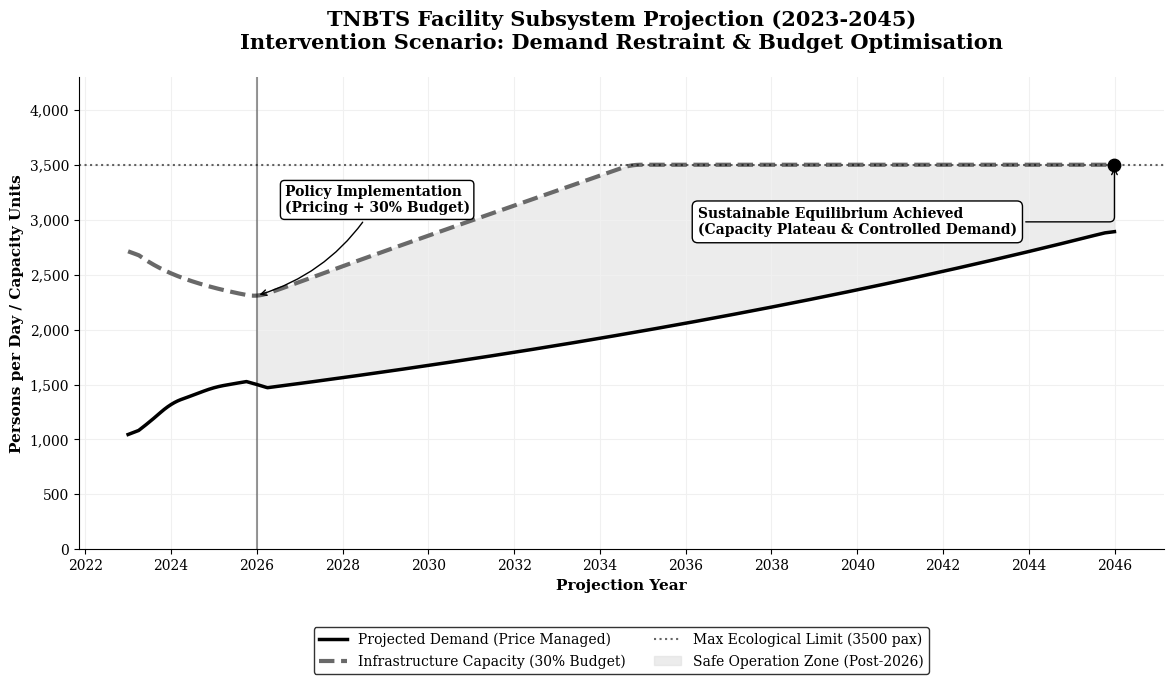

In [ ]:
# ==========================================
# 4. VISUALISASI MONOKROM AKADEMIS (SIMPLIFIED INTERVENTION)
# ==========================================
plt.rcParams.update({
    'font.family': 'serif', 'axes.facecolor': 'white', 'figure.facecolor': 'white',
    'text.color': 'black', 'axes.labelcolor': 'black', 'xtick.color': 'black',
    'ytick.color': 'black', 'axes.grid': True, 'grid.color': '#f0f0f0',
    'grid.linestyle': '-', 'legend.frameon': True, 'legend.edgecolor': 'black'
})

fig, ax = plt.subplots(figsize=(14, 7.5))
plt.subplots_adjust(bottom=0.25) # Margin bawah lebih ramping karena legend berkurang

# Plot Intervensi Saja
ax.plot(df["Date"], df["Vis_INT_Smooth"], color="black", linestyle="-", linewidth=2.5, label="Projected Demand (Price Managed)")
ax.plot(df["Date"], df["Cap_INT_Smooth"], color="dimgray", linestyle="--", linewidth=3.0, label="Infrastructure Capacity (30% Budget)")

# Garis Batas Alam
ax.axhline(y=max_physical_capacity, color="black", linestyle=":", linewidth=1.5, alpha=0.6, label=f"Max Ecological Limit ({max_physical_capacity} pax)")

# Arsiran Zona Nyaman (Fasilitas > Turis)
df_shaded = df[df["Date"] >= pd.Timestamp("2026-01-01")]
ax.fill_between(df_shaded["Date"], df_shaded["Cap_INT_Smooth"], df_shaded["Vis_INT_Smooth"],
                where=(df_shaded["Cap_INT_Smooth"] >= df_shaded["Vis_INT_Smooth"]),
                color="#e0e0e0", alpha=0.6, label="Safe Operation Zone (Post-2026)")

# ------------------------------------------
# ANOTASI KEBIJAKAN & KEBERHASILAN
# ------------------------------------------
# 1. Eksekusi Intervensi 2026
batas_int = pd.Timestamp("2026-01-01")
y_int = df.loc[df["Date"] == batas_int, "Cap_INT_Smooth"].values[0]
ax.axvline(x=batas_int, color="black", linestyle="-", linewidth=1.5, alpha=0.4)
ax.annotate("Policy Implementation\n(Pricing + 30% Budget)",
            xy=(batas_int, y_int), xytext=(20, 60), textcoords="offset points",
            fontsize=10, weight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"),
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3,rad=-0.2", color="black"))

# 2. Keberhasilan di Masa Depan
end_date_val = df["Date"].iloc[-1]
end_cap_val = df["Cap_INT_Smooth"].iloc[-1]
ax.scatter(end_date_val, end_cap_val, color="black", s=80, zorder=6)
ax.annotate("Sustainable Equilibrium Achieved\n(Capacity Plateau & Controlled Demand)",
            xy=(end_date_val, end_cap_val), xytext=(-300, -50), textcoords="offset points",
            fontsize=10, weight='bold', bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black"),
            arrowprops=dict(arrowstyle="->", connectionstyle="angle,angleA=0,angleB=90,rad=5", color="black"))

# Formatting Sumbu
ax.set_title("TNBTS Facility Subsystem Projection (2023-2045)\nIntervention Scenario: Demand Restraint & Budget Optimisation", fontsize=15, fontweight="bold", pad=20)
ax.set_ylabel("Persons per Day / Capacity Units", fontsize=11, fontweight="bold")
ax.set_xlabel("Projection Year", fontsize=11, fontweight="bold")

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# Auto-Scaling Aman
max_y = df["Cap_INT_Smooth"].max()
ax.set_ylim(0, max_y + 800)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legend 2 kolom di bawah (Sangat Rapi)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=10, frameon=True, edgecolor="black")

plt.show()

In [ ]:
# ==========================================
# 5. EKSPOR DATA TAHUNAN (INTERVENSI SAJA)
# ==========================================
df["Year"] = df["Date"].dt.year
df_annual = df.groupby("Year").agg(
    Vis_INT=("Vis_INT_Smooth", "mean"), Cap_INT=("Cap_INT_Smooth", "mean")
).reset_index()

print("\n" + "=" * 80)
print("   TABEL PROYEKSI FASILITAS TNBTS (SKENARIO INTERVENSI)")
print("=" * 80)
print(f"{'Tahun':<6} | {'Permintaan (Jiwa/Hari)':<25} | {'Kapasitas INT':<15} | {'Status'}")
print("-" * 80)

for _, row in df_annual[df_annual["Year"] >= 2024].iterrows():
    year = int(row["Year"])
    vis = row["Vis_INT"]
    cap = row["Cap_INT"]
    status_int = "SAFE (Controlled)" if vis <= cap else "DEFICIT"

    print(f"{year:<6} | {vis:>23,.0f} | {cap:>15,.0f} | {status_int}")
print("=" * 80)


   TABEL PROYEKSI FASILITAS TNBTS (SKENARIO INTERVENSI)
Tahun  | Permintaan (Jiwa/Hari)    | Kapasitas INT   | Status
--------------------------------------------------------------------------------
2024   |                   1,400 |           2,441 | SAFE (Controlled)
2025   |                   1,504 |           2,338 | SAFE (Controlled)
2026   |                   1,489 |           2,365 | SAFE (Controlled)
2027   |                   1,536 |           2,505 | SAFE (Controlled)
2028   |                   1,590 |           2,646 | SAFE (Controlled)
2029   |                   1,645 |           2,786 | SAFE (Controlled)
2030   |                   1,703 |           2,923 | SAFE (Controlled)
2031   |                   1,763 |           3,059 | SAFE (Controlled)
2032   |                   1,824 |           3,196 | SAFE (Controlled)
2033   |                   1,888 |           3,333 | SAFE (Controlled)
2034   |                   1,954 |           3,464 | SAFE (Controlled)
2035   |           